In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
tickers=["GOLDBEES.NS", "OIL.NS", "^NSEI", "HCLTECH.NS"]
data=yf.download(tickers, start="2020-01-01", end="2026-01-01")["Close"]
data=data.dropna()

C:\Users\SHREYA PAI\AppData\Local\Temp\ipykernel_12712\1597424220.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(tickers, start="2020-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  4 of 4 completed


In [3]:
returns = data.pct_change().dropna()
returns=returns*100
cum_returns=(1+returns).cumprod()
returns

Ticker,GOLDBEES.NS,HCLTECH.NS,OIL.NS,^NSEI
Date,,,,
2020-01-02,0.000000,0.279741,0.558466,0.818389
2020-01-03,3.056778,2.005076,1.894798,-0.452279
2020-01-06,2.118644,-0.521343,-1.346574,-1.910585
2020-01-07,-1.798068,0.386613,0.389996,0.499459
2020-01-08,1.690137,0.256732,0.291371,-0.228994
...,...,...,...,...
2025-12-24,0.097260,-0.309549,-0.329072,-0.133898
2025-12-26,0.971644,-0.824024,-1.504031,-0.381755
2025-12-29,-1.119761,-1.812272,0.881431,-0.384763


In [4]:
mu=returns.mean()
cov=returns.cov()
corr=returns.corr()

L=np.linalg.cholesky(cov)
weights=np.ones(len(tickers))/len(tickers)

**Volatility Shock**

In [5]:
vol_stress_cov=2*cov
L_vol_stress=np.linalg.cholesky(vol_stress_cov)

**Drawdown Regime**

In [6]:
rolling_max=data.cummax()
drawdown=(data-rolling_max)/rolling_max

threshold=-0.15
crisis_days=drawdown.min(axis=1)<threshold
crisis_returns=returns[crisis_days]

mu_crisis=crisis_returns.mean()
dd_crisis_cov=crisis_returns.cov()
L_dd_crisis=np.linalg.cholesky(dd_crisis_cov)

C:\Users\SHREYA PAI\AppData\Local\Temp\ipykernel_12712\3217457166.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  crisis_returns=returns[crisis_days]


**Combined Crisis**

In [7]:
cov_combined=vol_stress_cov*dd_crisis_cov
L_combined=np.linalg.cholesky(cov_combined)

**Unified Simulation Function**

In [8]:
def run_simulation(mu, L, weights, n_simulations=10000):
    results=[]
    
    for _ in range(n_simulations):
        Z=np.random.normal(size=len(weights))
        simulated=mu.values + L @ Z
        portfolio_return=np.dot(weights, simulated)
        results.append(portfolio_return)
        
    return np.array(results)

In [9]:
sim_normal=run_simulation(mu, L, weights, 10000)
sim_vol=run_simulation(mu, L_vol_stress, weights, 10000)
sim_dd=run_simulation(mu_crisis, L_dd_crisis, weights, 10000)
sim_combined=run_simulation(mu_crisis, L_combined, weights, 10000)

In [10]:
def risk_metrics_95(sim):
    var_95=np.percentile(sim, 5)
    es_95=sim[sim<=var_95].mean()
    return var_95, es_95

In [11]:
def risk_metrics_99(sim):
    var_99=np.percentile(sim, 1)
    es_99=sim[sim<=var_99].mean()
    return var_99, es_99

In [12]:
var_n_95, es_n_95 = np.round(risk_metrics_95(sim_normal), 3)
var_v_95, es_v_95 = np.round(risk_metrics_95(sim_vol), 3)
var_dd_95, es_dd_95 = np.round(risk_metrics_95(sim_dd), 3)
var_c_95, es_c_95 = np.round(risk_metrics_95(sim_combined), 3)

In [13]:
var_n_99, es_n_99 = np.round(risk_metrics_99(sim_normal), 3)
var_v_99, es_v_99 = np.round(risk_metrics_99(sim_vol), 3)
var_dd_99, es_dd_99 = np.round(risk_metrics_99(sim_dd), 3)
var_c_99, es_c_99 = np.round(risk_metrics_99(sim_combined), 3)

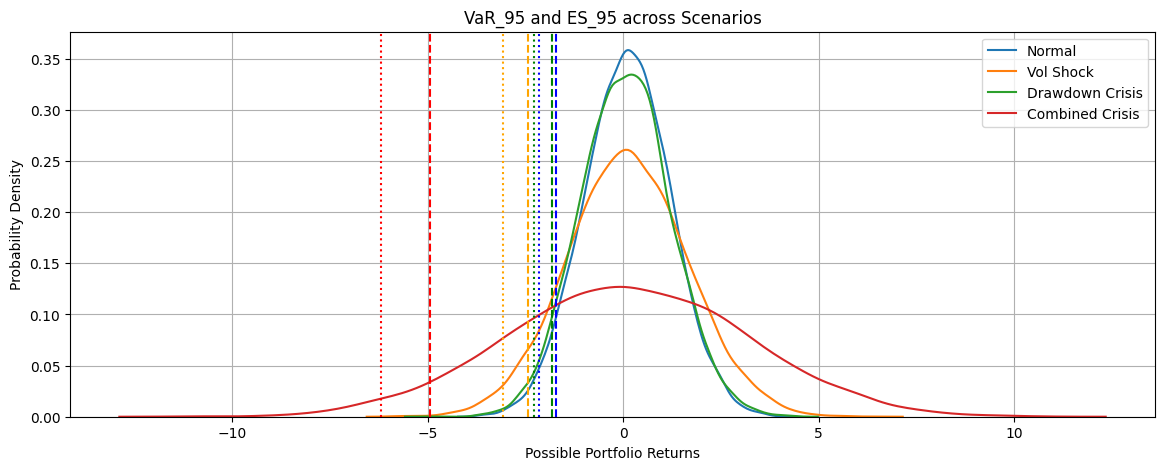

In [14]:
plt.figure(figsize=(14, 5))

sns.kdeplot(sim_normal, label="Normal")
sns.kdeplot(sim_vol, label="Vol Shock")
sns.kdeplot(sim_dd, label="Drawdown Crisis")
sns.kdeplot(sim_combined, label="Combined Crisis")

plt.axvline(var_n_95, linestyle='--', color='blue')
plt.axvline(var_v_95, linestyle='--', color='orange')
plt.axvline(var_dd_95, linestyle='--', color='green')
plt.axvline(var_c_95, linestyle='--', color='red')

plt.axvline(es_n_95, linestyle=':', color='blue')
plt.axvline(es_v_95, linestyle=':', color='orange')
plt.axvline(es_dd_95, linestyle=':', color='green')
plt.axvline(es_c_95, linestyle=':', color='red')

plt.legend()
plt.grid()
plt.title("VaR_95 and ES_95 across Scenarios")
plt.xlabel("Possible Portfolio Returns")
plt.ylabel("Probability Density")
plt.show()

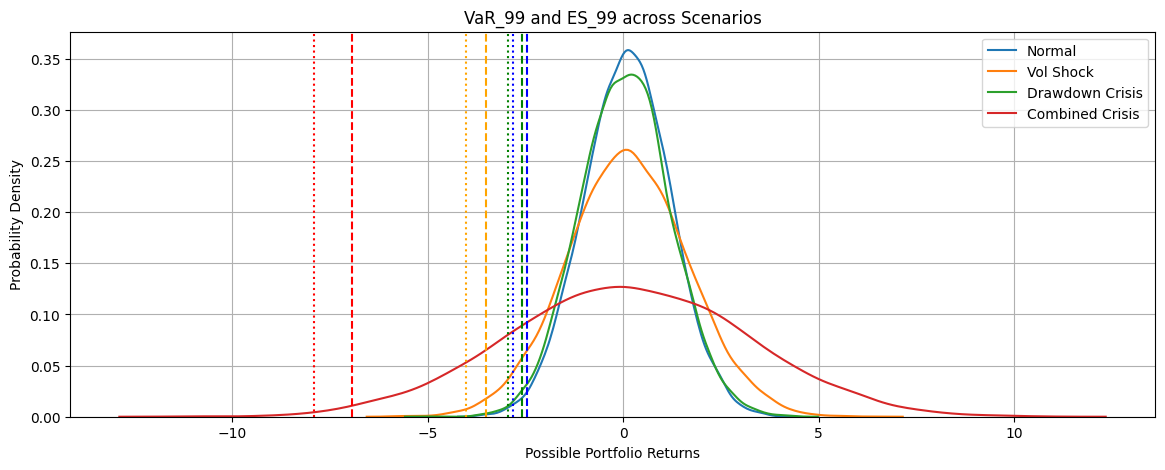

In [15]:
plt.figure(figsize=(14, 5))

sns.kdeplot(sim_normal, label="Normal")
sns.kdeplot(sim_vol, label="Vol Shock")
sns.kdeplot(sim_dd, label="Drawdown Crisis")
sns.kdeplot(sim_combined, label="Combined Crisis")

plt.axvline(var_n_99, linestyle='--', color='blue')
plt.axvline(var_v_99, linestyle='--', color='orange')
plt.axvline(var_dd_99, linestyle='--', color='green')
plt.axvline(var_c_99, linestyle='--', color='red')

plt.axvline(es_n_99, linestyle=':', color='blue')
plt.axvline(es_v_99, linestyle=':', color='orange')
plt.axvline(es_dd_99, linestyle=':', color='green')
plt.axvline(es_c_99, linestyle=':', color='red')


plt.legend()
plt.grid()
plt.title("VaR_99 and ES_99 across Scenarios")
plt.xlabel("Possible Portfolio Returns")
plt.ylabel("Probability Density")
plt.show()

In [16]:
portfolio_returns=returns@weights

In [17]:
stress_regime=np.where(
    portfolio_returns<es_n_95, "Severe Stress",
    np.where(portfolio_returns<var_n_95, "Moderate Stress", "Normal")
)    

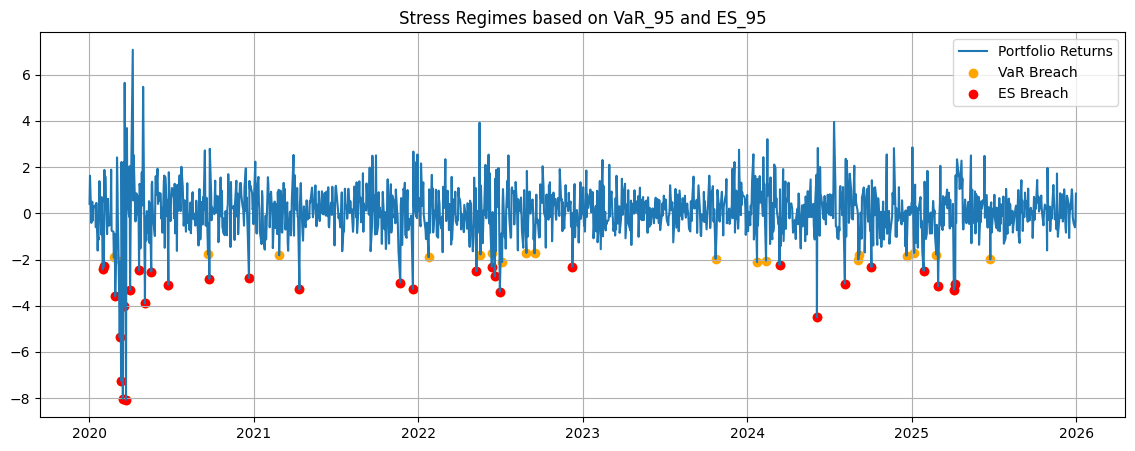

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(portfolio_returns, label="Portfolio Returns")

plt.scatter(
    portfolio_returns.index[portfolio_returns<var_n_95],
    portfolio_returns[portfolio_returns<var_n_95],
    color='orange',
    label="VaR Breach"
)

plt.scatter(
    portfolio_returns.index[portfolio_returns<es_n_95],
    portfolio_returns[portfolio_returns<es_n_95],
    color='red',
    label="ES Breach"
)

plt.legend()
plt.grid()
plt.title("Stress Regimes based on VaR_95 and ES_95")
plt.show()

In [19]:
stress_regime=np.where(
    portfolio_returns<es_n_99, "Severe Stress",
    np.where(portfolio_returns<var_n_99, "Moderate Stress", "Normal")
)    

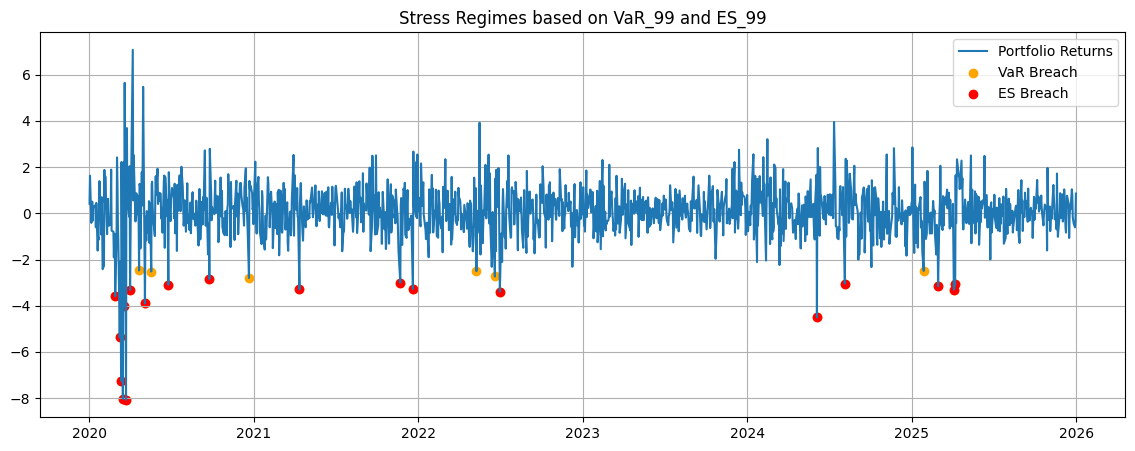

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(portfolio_returns, label="Portfolio Returns")

plt.scatter(
    portfolio_returns.index[portfolio_returns<var_n_99],
    portfolio_returns[portfolio_returns<var_n_99],
    color='orange',
    label="VaR Breach"
)

plt.scatter(
    portfolio_returns.index[portfolio_returns<es_n_99],
    portfolio_returns[portfolio_returns<es_n_99],
    color='red',
    label="ES Breach"
)

plt.legend()
plt.grid()
plt.title("Stress Regimes based on VaR_99 and ES_99")
plt.show()

**How often does stress happen?**

In [21]:
stress_var_95 = portfolio_returns<var_n_95
stress_es_95=portfolio_returns<es_n_95

stress_var_99 = portfolio_returns<var_n_99
stress_es_99=portfolio_returns<es_n_99

In [22]:
total_days=len(portfolio_returns)

VaR 95 Breach days:  50
VaR 95 Breach percentage:  3.369
ES 95 Breach days:  31
ES 95 Breach percentage:  2.089


VaR 99 Breach days:  25
VaR 99 Breach percentage:  1.685
ES 99 Breach days:  19
ES 99 Breach percentage:  1.28


In [52]:
stress_dict={
    "VaR 95": stress_var_95, 
    "ES 95": stress_es_95, 
    "VaR 99":stress_var_99, 
    "ES 99": stress_es_99}

In [59]:
for label, condition in stress_dict.items():
    stress_dates=portfolio_returns.index[condition]

    stress_periods=[]
    current_period=[]

    for i in range(len(stress_dates)):
        if i==0:
            current_period=[stress_dates[i]]
            continue
            
        if(stress_dates[i]-stress_dates[i-1]).days==1:
            current_period.append(stress_dates[i])
        else:
            stress_periods.append(current_period)
            current_period=[stress_dates[i]]

    if current_period:
        stress_periods.append(current_period)

    print(f"\n---{label}---")

    for period in stress_periods:
        if len(period)<=2:
            print(period[0], "to", period[-1], "Length:", len(period))


---VaR 95---
2020-01-31 00:00:00 to 2020-01-31 00:00:00 Length: 1
2020-02-03 00:00:00 to 2020-02-03 00:00:00 Length: 1
2020-02-25 00:00:00 to 2020-02-25 00:00:00 Length: 1
2020-02-28 00:00:00 to 2020-02-28 00:00:00 Length: 1
2020-03-09 00:00:00 to 2020-03-09 00:00:00 Length: 1
2020-03-11 00:00:00 to 2020-03-12 00:00:00 Length: 2
2020-03-16 00:00:00 to 2020-03-16 00:00:00 Length: 1
2020-03-19 00:00:00 to 2020-03-19 00:00:00 Length: 1
2020-03-23 00:00:00 to 2020-03-23 00:00:00 Length: 1
2020-04-01 00:00:00 to 2020-04-01 00:00:00 Length: 1
2020-04-21 00:00:00 to 2020-04-21 00:00:00 Length: 1
2020-05-04 00:00:00 to 2020-05-04 00:00:00 Length: 1
2020-05-18 00:00:00 to 2020-05-18 00:00:00 Length: 1
2020-06-25 00:00:00 to 2020-06-25 00:00:00 Length: 1
2020-09-21 00:00:00 to 2020-09-21 00:00:00 Length: 1
2020-09-24 00:00:00 to 2020-09-24 00:00:00 Length: 1
2020-12-21 00:00:00 to 2020-12-21 00:00:00 Length: 1
2021-02-26 00:00:00 to 2021-02-26 00:00:00 Length: 1
2021-04-12 00:00:00 to 2021-04-1

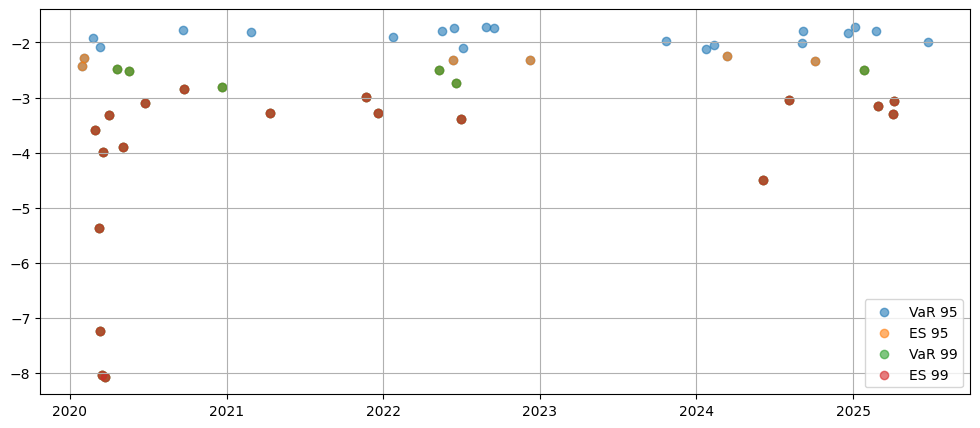

In [76]:
plt.figure(figsize=(12, 5))

plt.plot(portfoloio_returns="Portfolio Returns")

plt.scatter(
    portfolio_returns.index[stress_var_95],
    portfolio_returns[stress_var_95],
    label="VaR 95",
    alpha=0.6
)   

plt.scatter(
    portfolio_returns.index[stress_es_95],
    portfolio_returns[stress_es_95],
    label="ES 95",
    alpha=0.6
)   

plt.scatter(
    portfolio_returns.index[stress_var_99],
    portfolio_returns[stress_var_99],
    label="VaR 99",
    alpha=0.6
)   

plt.scatter(
    portfolio_returns.index[stress_es_99],
    portfolio_returns[stress_es_99],
    label="ES 99",
    alpha=0.6
)   

plt.legend()
plt.grid()

In [79]:
var_days_95=stress_var_95.sum()
es_days_95=stress_es_95.sum()

print("VaR 95 Breach days: ", var_days_95)
print("VaR 95 Breach percentage: ", round((var_days_95/total_days)*100, 3), "%")
print("ES 95 Breach days: ", es_days_95)
print("ES 95 Breach percentage: ", round((es_days_95/total_days)*100, 3), "%")

VaR 95 Breach days:  50
VaR 95 Breach percentage:  3.369 %
ES 95 Breach days:  31
ES 95 Breach percentage:  2.089 %


In [80]:
var_days_99=stress_var_99.sum()
es_days_99=stress_es_99.sum()

print("VaR 99 Breach days: ", var_days_99)
print("VaR 99 Breach percentage: ", round((var_days_99/total_days)*100, 3), "%")
print("ES 99 Breach days: ", es_days_99)
print("ES 99 Breach percentage: ", round((es_days_99/total_days)*100, 3), "%")

VaR 99 Breach days:  25
VaR 99 Breach percentage:  1.685 %
ES 99 Breach days:  19
ES 99 Breach percentage:  1.28 %


In [83]:
print("Normal")
print("VaR 95: ", var_n_95)
print("ES 95: ", es_n_95)
print("VaR 99: ", var_n_99)
print("ES 99: ", es_n_99)

print("\nVolatility Shocks:")
print("VaR 95: ", var_v_95)
print("ES 95: ", es_v_95)
print("VaR 99: ", var_v_99)
print("ES 99: ", es_v_99)

print("\nDrawdown Crisis:")
print("VaR 95: ", var_dd_95)
print("ES 95: ", es_dd_95)
print("VaR 99: ", var_dd_99)
print("ES 99: ", es_dd_99)

print("\nCombines Crisis:")
print("VaR 95: ", var_c_95)
print("ES 95: ", es_c_95)
print("VaR 99: ", var_c_99)
print("ES 99: ", es_c_99)

Normal
VaR 95:  -1.714
ES 95:  -2.166
VaR 99:  -2.452
ES 99:  -2.827

Volatility Shocks:
VaR 95:  -2.427
ES 95:  -3.075
VaR 99:  -3.503
ES 99:  -4.025

Drawdown Crisis:
VaR 95:  -1.814
ES 95:  -2.283
VaR 99:  -2.585
ES 99:  -2.954

Combines Crisis:
VaR 95:  -4.932
ES 95:  -6.209
VaR 99:  -6.932
ES 99:  -7.911


In [73]:
print("Expected VaR 95 Breaches \u2248 5%")
print("Actual VaR 95 Breaches: ", round((var_days_95/total_days)*100, 3), "%")

print("Expected VaR 99 Breaches \u2248 1%")
print("Actual VaR 99 Breaches: ", round((var_days_99/total_days)*100, 3), "%")

Expected VaR 95 Breaches ≈ 5%
Actual VaR 95 Breaches:  3.369 %
Expected VaR 99 Breaches ≈ 1%
Actual VaR 99 Breaches:  1.685 %
